In [1]:
import torch
import torch.nn as nn
import torch.optim as optim

from torch.distributions import Categorical
import gymnasium as gym
import numpy as np

In [2]:
GAMMA = 0.99
LAMBDA = 0.95
EPSILON = 0.2
LR = 3e-3

ROLLOUT_STEPS = 500
UPDATES = 150

In [3]:
class ActorCritic(nn.Module):
    def __init__(self, state_dim, action_dim):
        super().__init__()

        self.body = nn.Sequential(
            nn.Linear(state_dim, 64),
            nn.Tanh()
        )

        # Produces scores for Left and Right actions
        self.actor = nn.Linear(64, action_dim)

        # Estimates the value of the current state
        self.critic = nn.Linear(64, 1)

    def forward(self, x):
        x = self.body(x)

        action_logits = self.actor(x)
        state_value = self.critic(x).squeeze(-1)

        return action_logits, state_value

In [7]:
def compute_gae(rewards, values, next_value, dones):
    values = values + [next_value]

    advantages = [0] * len(rewards)
    gae = 0

    for t in reversed(range(len(rewards))):
        mask = 1 - int(dones[t])

        delta = (
            rewards[t]
            + GAMMA * values[t + 1] * mask
            - values[t]
        )

        gae = delta + GAMMA * LAMBDA * mask * gae
        advantages[t] = gae

    returns = [
        advantage + value
        for advantage, value in zip(advantages, values[:-1])
    ]

    return advantages, returns

In [9]:
def train():
    env = gym.make("CartPole-v1")

    state_dim = env.observation_space.shape[0]
    action_dim = env.action_space.n

    model = ActorCritic(state_dim, action_dim)
    optimizer = optim.Adam(model.parameters(), lr=LR)

    state, _ = env.reset()

    reward_history = []

    for update in range(UPDATES):
        states = []
        actions = []
        rewards = []
        dones = []
        old_log_probs = []
        old_values = []

        # 1. Collect experience
        for _ in range(ROLLOUT_STEPS):
            state_tensor = torch.tensor(
                state,
                dtype=torch.float32
            )

            with torch.no_grad():
                logits, value = model(state_tensor)
                distribution = Categorical(logits=logits)
                action = distribution.sample()
                log_probability = distribution.log_prob(action)

            next_state, reward, terminated, truncated, _ = env.step(
                action.item()
            )

            done = terminated or truncated

            states.append(state)
            actions.append(action.item())
            rewards.append(reward)
            dones.append(done)
            old_log_probs.append(log_probability.item())
            old_values.append(value.item())

            if done:
                state, _ = env.reset()
            else:
                state = next_state

        with torch.no_grad():
            _, next_value = model(
                torch.tensor(state, dtype=torch.float32)
            )

        # 2. Calculate advantages and returns
        advantages, returns = compute_gae(
            rewards,
            old_values,
            next_value.item(),
            dones
        )

        states_t = torch.tensor(
            np.array(states),
            dtype=torch.float32
        )

        actions_t = torch.tensor(
            actions,
            dtype=torch.long
        )

        old_log_probs_t = torch.tensor(
            old_log_probs,
            dtype=torch.float32
        )

        old_values_t = torch.tensor(
            old_values,
            dtype=torch.float32
        )

        returns_t = torch.tensor(
            returns,
            dtype=torch.float32
        )

        advantages_t = torch.tensor(
            advantages,
            dtype=torch.float32
        )

        advantages_t = (
            advantages_t - advantages_t.mean()
        ) / (advantages_t.std() + 1e-8)

        # 3. PPO update
        logits, values_pred = model(states_t)

        distribution = Categorical(logits=logits)
        new_log_probs = distribution.log_prob(actions_t)
        entropy = distribution.entropy().mean()

        ratio = torch.exp(
            new_log_probs - old_log_probs_t
        )

        surr1 = ratio * advantages_t

        surr2 = torch.clamp(
            ratio,
            1 - EPSILON,
            1 + EPSILON
        ) * advantages_t

        policy_loss = -torch.min(surr1, surr2).mean()

        value_clipped = old_values_t + torch.clamp(
            values_pred - old_values_t,
            -EPSILON,
            EPSILON
        )

        value_loss_unclipped = (
            values_pred - returns_t
        ) ** 2

        value_loss_clipped = (
            value_clipped - returns_t
        ) ** 2

        value_loss = 0.5 * torch.max(
            value_loss_unclipped,
            value_loss_clipped
        ).mean()

        loss = (
            policy_loss
            + 0.5 * value_loss
            - 0.01 * entropy
        )

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        completed_episodes = max(1, sum(dones))
        average_reward = sum(rewards) / completed_episodes
        reward_history.append(average_reward)

        if update % 10 == 0:
            print(
                f"Update: {update} | "
                f"Average reward: {average_reward:.1f} | "
                f"Entropy: {entropy.item():.3f}"
            )

    env.close()

    return model, reward_history

In [11]:
trained_model, rewards = train()

Update: 0 | Average reward: 22.7 | Entropy: 0.690
Update: 10 | Average reward: 45.5 | Entropy: 0.669
Update: 20 | Average reward: 45.5 | Entropy: 0.626
Update: 30 | Average reward: 55.6 | Entropy: 0.637
Update: 40 | Average reward: 83.3 | Entropy: 0.627
Update: 50 | Average reward: 250.0 | Entropy: 0.634
Update: 60 | Average reward: 83.3 | Entropy: 0.611
Update: 70 | Average reward: 62.5 | Entropy: 0.612
Update: 80 | Average reward: 100.0 | Entropy: 0.605
Update: 90 | Average reward: 125.0 | Entropy: 0.608
Update: 100 | Average reward: 100.0 | Entropy: 0.623
Update: 110 | Average reward: 166.7 | Entropy: 0.634
Update: 120 | Average reward: 100.0 | Entropy: 0.615
Update: 130 | Average reward: 125.0 | Entropy: 0.630
Update: 140 | Average reward: 83.3 | Entropy: 0.624


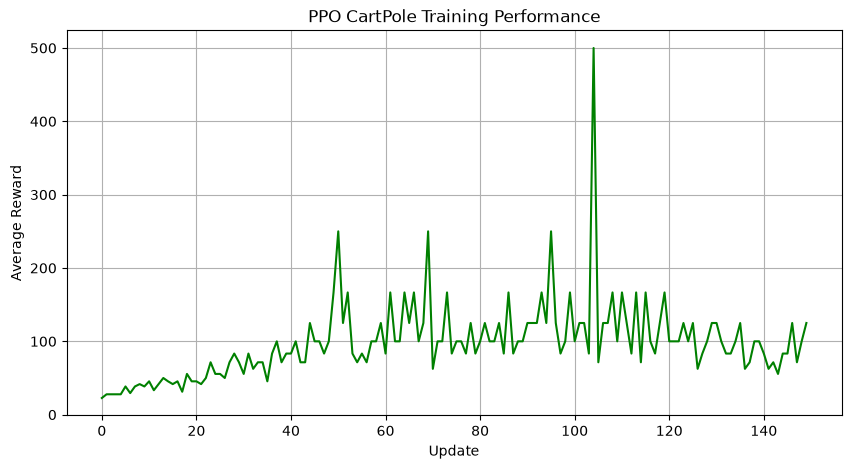

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(rewards, color="green")
plt.title("PPO CartPole Training Performance")
plt.xlabel("Update")
plt.ylabel("Average Reward")
plt.grid()
plt.show()